<a href="https://colab.research.google.com/github/Harsha-G17/financial-contagion-simulator/blob/main/Finance_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Financial Contagion and Liquidity Crisis Simulator
## Version 1: Fund fire-sale contagion

### Objective
Explore how investor withdrawals cause forced bond sales,
price declines and additional losses across funds.

### Data
Bank of England nominal spot curves, 2016–2024.
Simulation maturities: 2, 5, 10, 20 and 30 years.
Historical yield changes are applied as instantaneous shocks.

### Model
Five synthetic funds hold zero-coupon bond portfolios and cash.
Withdrawals depend on a base rate and investment losses.
Funds use cash first, then sell bonds proportionally.
Combined sales cause a common price decline.
Additional losses can trigger further withdrawal rounds.

### Validation
- Fund accounting balances.
- Zero price impact produces zero contagion losses.
- Sufficient cash prevents forced selling.
- Exhausted holdings leave unpaid withdrawals.
- Notebook runs from a restarted session.

### Findings
All 2,272 tested historical intervals settled under the
tested two-fund assumptions.
Increasing price impact increased losses and selling rounds.
Funds could suffer contagion losses without selling themselves.

### Limitations
Fund holdings, cash, withdrawal behaviour and market depth
are synthetic assumptions, not calibrated estimates.
Price impact is shared across maturities.
Tests are independent scenarios, not a continuous backtest.
Banks, leverage, margin calls and funding networks are excluded.
Results are simulated outcomes, not observed fund losses.

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("nominal_spot_observed.csv")
df=df.rename(columns={"tenor_years":"tenor_year"})

df["date"]=pd.to_datetime(
    df["date"],dayfirst=True,errors="raise"
)
df["tenor_year"]=pd.to_numeric(
    df["tenor_year"],errors="raise"
)

df["spot_rate_decimal"]=pd.to_numeric(
    df["spot_rate_decimal"],errors="raise"
)

assert not df.duplicated(["date","tenor_year"]).any(),\
"Duplicate date/maturity observations found"

df=df.sort_values(["tenor_year","date"])
df["change_dps"]=(
    df.groupby("tenor_year")["spot_rate_decimal"].diff()*10000
    )
print("Rows:",len(df))
print("Date range:",df["date"].min(),"to",df["date"].max())
print(df[["date","tenor_year","spot_rate_decimal","change_dps"]].head())

Rows: 284178
Date range: 2016-01-04 00:00:00 to 2024-12-31 00:00:00
        date  tenor_year  spot_rate_decimal  change_dps
0 2016-06-07        0.25           0.004360         NaN
1 2016-10-21        0.25           0.001500   -28.60840
2 2017-05-25        0.25           0.000358   -11.41337
3 2017-06-07        0.25           0.000786     4.27346
4 2017-12-05        0.25           0.002729    19.43739


In [ ]:
tenors=[2,5,10,20,30]

rates=(
    df[df["tenor_year"].isin(tenors)]
    .pivot(
        index="date",
        columns="tenor_year",
        values="spot_rate_decimal"
    )
    .sort_index()
    .reindex(columns=tenors)
)
shocks_bps=rates.diff()*10000

valid = shocks_bps.notna().all(axis=1)
historical_shocks=shocks_bps.loc[valid].copy()

previous_dates= rates.index.to_series().shift(1)
historical_shocks.insert(0,"previous_date",previous_dates.loc[valid]
                         )

print("complete shock intervals:",len(historical_shocks))
print(historical_shocks.head())

complete shock intervals: 2272
tenor_year previous_date        2        5       10       20       30
date                                                                 
2016-01-05    2016-01-04 -1.77545 -1.45572 -0.42918 -0.75329 -0.45052
2016-01-06    2016-01-05 -5.83564 -7.26623 -8.56344 -7.00342 -6.55251
2016-01-07    2016-01-06  0.60154 -0.03485  1.43400  2.87870  3.75176
2016-01-08    2016-01-07 -2.28697 -4.13205 -3.72902 -2.23682 -1.80074
2016-01-11    2016-01-08 -0.60161  0.06685  0.48000  1.09637  1.43647


In [ ]:
import numpy as np

shock_date=historical_shocks.index[-1]
shock=historical_shocks.loc[shock_date,tenors].to_numpy(dtype=float)

initial_values=np.full(len(tenors),200_000.0)
maturities=np.array(tenors,dtype=float)

price_factors=np.exp(-maturities*shock/10_000)
values_after_shock=initial_values*price_factors

result=pd.DataFrame({
    "tenor_year":maturities,
    "shock_bps":shock,
    "initial_value_gbp":initial_values,
    "value_after_shock_gbp":values_after_shock,
    "pnl_gbp":values_after_shock-initial_values
})

print("shock interval:",
      historical_shocks.loc[shock_date,"previous_date"].date(),
      "to",shock_date.date())
print(result.round(2).to_string(index=False))
print("\n Total P&L (£):",round(result["pnl_gbp"].sum(),2))

shock interval: 2024-12-30 to 2024-12-31
 tenor_year  shock_bps  initial_value_gbp  value_after_shock_gbp  pnl_gbp
        2.0      -3.38           200000.0              200135.06   135.06
        5.0      -3.29           200000.0              200329.65   329.65
       10.0      -2.58           200000.0              200517.08   517.08
       20.0      -2.08           200000.0              200834.31   834.31
       30.0      -1.99           200000.0              201197.23  1197.23

 Total P&L (£): 3013.33


In [ ]:
holdings=np.array([
    [200_000,200_000,200_000,200_000,200_000],
    [100_000,100_000,100_000,100_000,100_000]
],dtype=float)

cash=np.array([50_000,30_000],dtype=float)

base_redemption=np.array([0.01,0.01])
sensitivity=np.array([0.5,0.5])

initial_nav=holdings.sum(axis=1)+cash
shocked_holdings=holdings*price_factors
shocked_nav=shocked_holdings.sum(axis=1)+cash

loss_fraction=np.maximum(
    0,(initial_nav-shocked_nav)/initial_nav
)

redemption_rate=np.clip(
    base_redemption + sensitivity*loss_fraction,0,1
)
redemption_request = redemption_rate * shocked_nav
cash_shortfall = np.maximum(0, redemption_request - cash)

fund_summary = pd.DataFrame({
    "fund": ["Fund A", "Fund B"],
    "initial_nav_gbp": initial_nav,
    "nav_after_shock_gbp": shocked_nav,
    "loss_pct": loss_fraction * 100,
    "cash_gbp": cash,
    "redemption_request_gbp": redemption_request,
    "cash_shortfall_gbp": cash_shortfall,
})

print(fund_summary.round(2).to_string(index=False))

  fund  initial_nav_gbp  nav_after_shock_gbp  loss_pct  cash_gbp  redemption_request_gbp  cash_shortfall_gbp
Fund A        1050000.0           1053013.33       0.0   50000.0                10530.13                 0.0
Fund B         530000.0            531506.67       0.0   30000.0                 5315.07                 0.0


In [ ]:
market_depth=shocked_holdings.sum()
impact_coefficient=0.10

bond_values=shocked_holdings.sum(axis=1)

def sales_needed(price_decline):
  return np.minimum(
      bond_values,
      cash_shortfall / (1-price_decline)
  )

low,high=0.0,impact_coefficient

for _ in range(60):
  midpoint=(low+high)/2
  implied_decline=(
      impact_coefficient * sales_needed(midpoint).sum()/market_depth
      )
  if midpoint > implied_decline:
    high=midpoint
  else:
    low=midpoint
price_decline=(low+high)/2
sales=sales_needed(price_decline)
sales_proceeds=sales*(1-price_decline)

sale_fraction=np.divide(
    sales,bond_values,
    out=np.zeros_like(sales),
    where=bond_values>0

  )
remaining_holding=(
    shocked_holdings
    *(1-sale_fraction[:,None])
    *(1-price_decline)
)

cash_before_payment = cash+sales_proceeds
paid_redemptions=np.minimum(
    redemption_request,cash_before_payment
)

remaining_cash=cash_before_payment-paid_redemptions
unpaid_redemptions=redemption_request-paid_redemptions

sale_summary=pd.DataFrame({
    "fund":["Fund A","Fund B"],
    "sale_proceeds_gbp":sales_proceeds,
    "remaining_bonds_gbp":remaining_holding.sum(axis=1),
    "remaining_cash_gbp":remaining_cash,
    "unpaid_redemptions_gbp":unpaid_redemptions,
})
print("Price decline (%):", round(price_decline*100,4))
print(sale_summary.round(2).to_string(index=False))


Price decline (%): 0.0
  fund  sale_proceeds_gbp  remaining_bonds_gbp  remaining_cash_gbp  unpaid_redemptions_gbp
Fund A                0.0           1003013.33            39469.87                     0.0
Fund B                0.0            501506.67            24684.93                     0.0


In [ ]:
assert np.all(remaining_holding >= -1e-8)
assert np.all(remaining_cash >= -1e-8)
assert np.all(unpaid_redemptions >= -1e-8)

assert np.allclose(
    paid_redemptions + unpaid_redemptions,
    redemption_request
)

nav_before_sales = shocked_holdings.sum(axis=1)+cash
nav_after_sales = remaining_holding.sum(axis=1)+remaining_cash
price_impact_loss=shocked_holdings.sum(axis=1)*price_decline

assert np.allclose(
    nav_before_sales,
    nav_after_sales + paid_redemptions + price_impact_loss
    )

print("Accounting checks passed.")
print(sale_summary.round(2).to_string(index=False))

Accounting checks passed.
  fund  sale_proceeds_gbp  remaining_bonds_gbp  remaining_cash_gbp  unpaid_redemptions_gbp
Fund A                0.0           1003013.33            39469.87                     0.0
Fund B                0.0            501506.67            24684.93                     0.0


In [ ]:
nav_before_round=shocked_holdings.sum(axis=1)+cash
new_loss_fraction=np.divide(
    price_impact_loss,
    nav_before_round,
    out=np.zeros_like(price_impact_loss),
    where=nav_before_round>0
)

additional_redemption_rate=np.clip(
    sensitivity * new_loss_fraction,0,1
)

current_nav=(
    remaining_holding.sum(axis=1)+remaining_cash
)
additional_requests=additional_redemption_rate * current_nav

next_requests=unpaid_redemptions + additional_requests
next_shortfalls=np.maximum(0,next_requests-remaining_cash)

next_round_summary=pd.DataFrame({
    "Fund":["Fund A","Fund B"],
    "new_loss_pct":new_loss_fraction*100,
    "additional_requests_gbp":additional_requests,
    "outstanding_requests_gbp":next_requests,
    "cash_shortfall_gbp":next_shortfalls,
})

print(next_round_summary.round(2).to_string(index=False))


  Fund  new_loss_pct  additional_requests_gbp  outstanding_requests_gbp  cash_shortfall_gbp
Fund A           0.0                      0.0                       0.0                 0.0
Fund B           0.0                      0.0                       0.0                 0.0


In [ ]:
base_redemption = np.array([0.05, 0.05])

In [ ]:
import numpy as np

# Historical shock
tenors = [2, 5, 10, 20, 30]
shock_date = historical_shocks.index[-1]
shock = historical_shocks.loc[
    shock_date, tenors
].to_numpy(dtype=float)

price_factors = np.exp(
    -np.array(tenors, dtype=float) * shock / 10_000
)

# Synthetic fund portfolios
holdings = np.array([
    [200_000, 200_000, 200_000, 200_000, 200_000],
    [100_000, 100_000, 200_000, 300_000, 300_000],
], dtype=float)

cash = np.array([50_000, 30_000], dtype=float)
base_redemption = np.array([0.05, 0.05])
sensitivity = np.array([0.5, 0.5])

shocked_holdings = holdings * price_factors

initial_nav = holdings.sum(axis=1) + cash
shocked_nav = shocked_holdings.sum(axis=1) + cash

loss_fraction = np.maximum(
    0, (initial_nav - shocked_nav) / initial_nav
)
redemption_request = (
    np.clip(base_redemption + sensitivity * loss_fraction, 0, 1)
    * shocked_nav
)

In [ ]:
def simulate_rounds(
    starting_holdings, starting_cash, first_requests,
    sensitivity, impact_coefficient=0.10, max_rounds=100
):
    h = starting_holdings.copy()
    c = starting_cash.copy()
    requests = first_requests.copy()

    depth = h.sum()
    history = []
    tolerance = 0.01
    status = "Round limit reached"

    assert depth > 0
    assert 0 <= impact_coefficient < 1

    for round_number in range(1, max_rounds + 1):
        bonds = h.sum(axis=1)
        nav_before = bonds + c
        shortfalls = np.maximum(0, requests - c)

        def required_sales(decline):
            return np.minimum(bonds, shortfalls / (1 - decline))

        low, high = 0.0, impact_coefficient

        for _ in range(60):
            midpoint = (low + high) / 2
            implied = (
                impact_coefficient
                * required_sales(midpoint).sum() / depth
            )

            if midpoint > implied:
                high = midpoint
            else:
                low = midpoint

        decline = (low + high) / 2
        sales = required_sales(decline)
        proceeds = sales * (1 - decline)

        fraction_sold = np.divide(
            sales, bonds,
            out=np.zeros_like(sales),
            where=bonds > 0
        )

        new_h = h * (1 - fraction_sold[:, None]) * (1 - decline)
        paid = np.minimum(requests, c + proceeds)
        new_c = c + proceeds - paid
        unpaid = np.maximum(0, requests - paid)

        impact_loss = bonds * decline
        nav_after = new_h.sum(axis=1) + new_c

        assert np.allclose(
            nav_before, nav_after + paid + impact_loss
        )

        loss_fraction = np.divide(
            impact_loss, nav_before,
            out=np.zeros_like(impact_loss),
            where=nav_before > 0
        )

        additional = (
            np.clip(sensitivity * loss_fraction, 0, 1)
            * nav_after
        )

        for i in range(len(c)):
            history.append({
                "round": round_number,
                "fund": f"Fund {chr(65 + i)}",
                "sales_before_impact_gbp": sales[i],
                "price_decline_pct": decline * 100,
                "impact_loss_gbp": impact_loss[i],
                "paid_redemptions_gbp": paid[i],
                "unpaid_redemptions_gbp": unpaid[i],
                "nav_gbp": nav_after[i],
            })

        # Update once per round, after recording both funds
        h, c = new_h, new_c
        requests = unpaid + additional

        if requests.max() <= tolerance:
            status = "Withdrawals settled"
            break

        if (
            additional.max() <= tolerance
            and np.all((unpaid <= tolerance) | (nav_after <= tolerance))
        ):
            status = "Stopped with unpaid withdrawals"
            break

    return pd.DataFrame(history), status


round_history, status = simulate_rounds(
    shocked_holdings, cash, redemption_request, sensitivity
)

print(status)
print(round_history.round(2).to_string(index=False))

Withdrawals settled
 round   fund  sales_before_impact_gbp  price_decline_pct  impact_loss_gbp  paid_redemptions_gbp  unpaid_redemptions_gbp   nav_gbp
     1 Fund A                  2653.89               0.12          1218.03              52650.67                     0.0 999144.64
     1 Fund B                 21716.21               0.12          1218.98              51689.84                     0.0 980887.93
     2 Fund A                   577.89               0.01            57.57                577.86                     0.0 998509.21
     2 Fund B                   578.33               0.01            56.51                578.30                     0.0 980253.12
     3 Fund A                    28.76               0.00             2.84                 28.76                     0.0 998477.61
     3 Fund B                    28.24               0.00             2.78                 28.24                     0.0 980222.09
     4 Fund A                     1.42               0.00      

In [ ]:
summary=round_history.groupby("fund").agg(
    rounds=("round","max"),
    total_sales_gbp=("sales_before_impact_gbp","sum"),
    total_contagion_loss_gbp=("impact_loss_gbp","sum"),
    total_paid_redemptions_gbp=("paid_redemptions_gbp","sum"),
    total_unpaid_redemptions_gbp=("unpaid_redemptions_gbp","last"),
    final_nav_gbp=("nav_gbp","last"),
)
print(summary.round(2).to_string())

        rounds  total_sales_gbp  total_contagion_loss_gbp  total_paid_redemptions_gbp  total_unpaid_redemptions_gbp  final_nav_gbp
fund                                                                                                                              
Fund A       5          3262.03                   1278.58                    53258.78                           0.0      998475.98
Fund B       5         22324.24                   1278.42                    52297.83                           0.0      980220.49


In [ ]:
comparison_rows=[]
for scenario, coefficient in [
    ("No price impact",0.0),
    ("with price impact",0.10),
]:
    history,outcome=simulate_rounds(
        shocked_holdings,
        cash,
        redemption_request,
        sensitivity,
        impact_coefficient=coefficient
    )

    comparison_rows.append({
        "scenario":scenario,
        "rounds":history["round"].max(),
        "forced_sales_gbp":history["sales_before_impact_gbp"].sum(),
        "contagion_loss_gbp":history["impact_loss_gbp"].sum(),
        "paid_redemptions_gbp":history["paid_redemptions_gbp"].sum(),
        "final_nav_gbp":history.groupby("fund")["nav_gbp"].last().sum(),
        "unpaid_redemptions_gbp":(
            history.groupby("fund")["unpaid_redemptions_gbp"]
            .last().sum()
        ),
        "status":outcome,
        })
    comparison = pd.DataFrame(comparison_rows)
    print(comparison.round(2).to_string(index=False))

       scenario  rounds  forced_sales_gbp  contagion_loss_gbp  paid_redemptions_gbp  final_nav_gbp  unpaid_redemptions_gbp              status
No price impact       1           24340.5                 0.0              104340.5     1982469.58                     0.0 Withdrawals settled
         scenario  rounds  forced_sales_gbp  contagion_loss_gbp  paid_redemptions_gbp  final_nav_gbp  unpaid_redemptions_gbp              status
  No price impact       1          24340.50                 0.0             104340.50     1982469.58                     0.0 Withdrawals settled
with price impact       5          25586.27              2557.0             105556.61     1978696.47                     0.0 Withdrawals settled


In [ ]:
stress_results = []

for coefficient in [0.0, 0.05, 0.10, 0.20, 0.30]:
    history, outcome = simulate_rounds(
        shocked_holdings,
        cash,
        redemption_request,
        sensitivity,
        impact_coefficient=coefficient
    )

    stress_results.append({
        "impact_coefficient": coefficient,
        "rounds": history["round"].max(),
        "contagion_loss_gbp": history["impact_loss_gbp"].sum(),
        "forced_sales_gbp": history["sales_before_impact_gbp"].sum(),
        "status": outcome,
    })

# These lines must be outside the loop
stress_table = pd.DataFrame(stress_results)
print(stress_table.round(2).to_string(index=False))

 impact_coefficient  rounds  contagion_loss_gbp  forced_sales_gbp              status
               0.00       1                0.00          24340.50 Withdrawals settled
               0.05       4             1247.02          24947.99 Withdrawals settled
               0.10       5             2557.00          25586.27 Withdrawals settled
               0.20       7             5385.48          26965.08 Withdrawals settled
               0.30       8             8530.12          28499.33 Withdrawals settled


In [ ]:
historical_results=[]
matruities=np.array(tenors,dtype=float)
starting_nav=holdings.sum(axis=1)+cash

for date,row in historical_shocks.iterrows():
  shock=row[tenors].to_numpy(dtype=float)
  factors=np.exp(-matruities * shock /10_000)

  stressed_holdings=holdings * factors
  stressed_nav=stressed_holdings.sum(axis=1)+cash

  loss_fraction=np.maximum(
      0,(starting_nav-stressed_nav)/starting_nav
  )

  requests=(
      np.clip(base_redemption + sensitivity * loss_fraction,0,1) * stressed_nav
  )

  history, outcome=simulate_rounds(
      stressed_holdings,cash,requests,sensitivity,
      impact_coefficient=0.10
  )

  historical_results.append({
      "date":date,
      "previous_date":row["previous_date"],
      "initial_market_pnl_gbp":(
          stressed_nav - starting_nav
          ).sum(),
      "rounds": history["round"].max(),
      "contagion_loss_gbp":history["impact_loss_gbp"].sum(),
      "forced_sales_gbp":history["sales_before_impact_gbp"].sum,
      "status":outcome,
  })

  historical_test=pd.DataFrame(historical_results)

  print(historical_test.nlargest(10,"contagion_loss_gbp").round(2).to_string(index=False))

Streaming output truncated to the last 5000 lines.
2022-09-23    2022-09-22               -74209.33       5             5887.59 <bound method Series.sum of 0    17051.334001\n1    39167.366536\n2     1314.140240\n3     1298.547887\n4       64.125935\n5       62.131167\n6        3.098610\n7        3.002222\n8        0.149726\n9        0.145069\nName: sales_before_impact_gbp, dtype: float64> Withdrawals settled
2022-10-05    2022-10-04               -58733.05       5             5207.41 <bound method Series.sum of 0    13360.383268\n1    36344.013215\n2     1168.560638\n3     1151.447492\n4       57.256952\n5       55.332528\n6        2.778470\n7        2.685084\n8        0.134828\n9        0.130297\nName: sales_before_impact_gbp, dtype: float64> Withdrawals settled
2022-09-22    2022-09-21               -54318.85       5             5012.25 <bound method Series.sum of 0    12804.984939\n1    35031.375165\n2     1124.430824\n3     1111.146813\n4       55.162446\n5       53.459878\n6     

In [ ]:
print("Historical scenarios:",len(historical_test))

print("\n Settlement outcomes:")
print(historical_test["status"].value_counts())

unsettled=historical_test[
    historical_test["status"] != "Withdrawals settled"
]

print("\n Scenarios that did not settle:",len(unsettled))

if not unsettled.empty:
  print(
      unsettled[
          ["date","previous_date","rounds","status"]
      ].head(10).to_string(index=False)
  )

print("\n Largest contagion losses:")
print(
    historical_test.nlargest(10,"contagion_loss_gbp")[
        [
          "date","previous_date",
          "initial_market_pnl_gbp","rounds","status"
      ]
      ].round(2).to_string(index=False)
  )

Historical scenarios: 2272

 Settlement outcomes:
status
Withdrawals settled    2272
Name: count, dtype: int64

 Scenarios that did not settle: 0

 Largest contagion losses:
      date previous_date  initial_market_pnl_gbp  rounds              status
2022-09-27    2022-09-26              -120530.46       5 Withdrawals settled
2022-09-26    2022-09-23              -116512.52       5 Withdrawals settled
2022-10-10    2022-10-07               -95103.43       5 Withdrawals settled
2020-03-18    2020-03-17               -87759.66       5 Withdrawals settled
2022-09-23    2022-09-22               -74209.33       5 Withdrawals settled
2022-10-05    2022-10-04               -58733.05       5 Withdrawals settled
2022-09-22    2022-09-21               -54318.85       5 Withdrawals settled
2020-03-13    2020-03-12               -51764.33       5 Withdrawals settled
2023-09-28    2023-09-27               -51048.43       5 Withdrawals settled
2022-10-14    2022-10-13               -50726.26       5

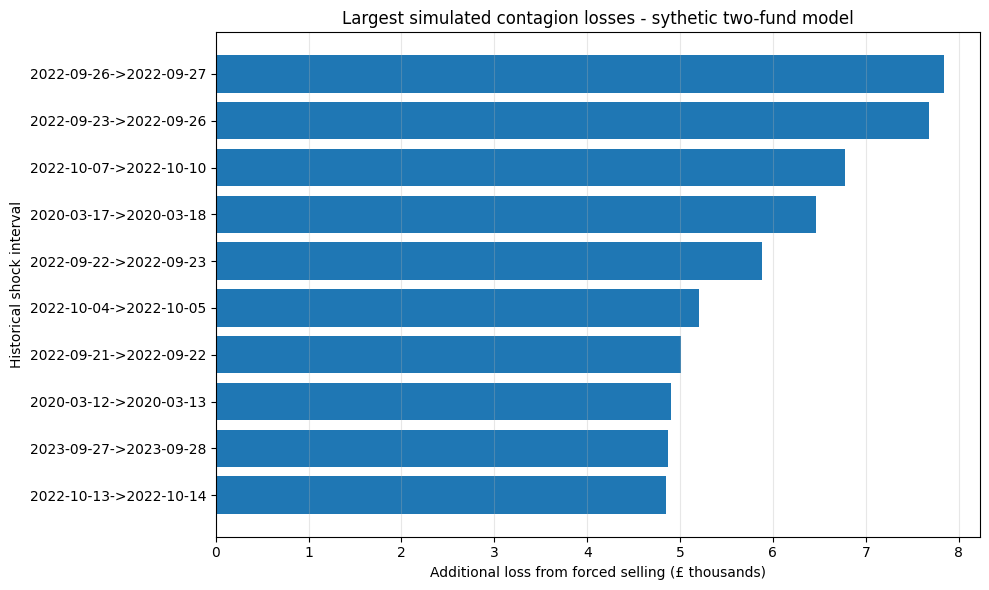

In [ ]:
#pip install matplotlib
import matplotlib.pyplot as plt

top10=(
    historical_test.nlargest(10,"contagion_loss_gbp")
    .sort_values("contagion_loss_gbp")
)

labels=(
    pd.to_datetime(top10["previous_date"]).dt.strftime("%Y-%m-%d")
    + "->"
    +pd.to_datetime(top10["date"]).dt.strftime("%Y-%m-%d")
)

fig,ax=plt.subplots(figsize=(10,6))

ax.barh(labels,top10["contagion_loss_gbp"]/1000)
ax.set_xlabel("Additional loss from forced selling (£ thousands)")
ax.set_ylabel("Historical shock interval")
ax.set_title("Largest simulated contagion losses - sythetic two-fund model")
ax.grid(axis="x",alpha=0.3)

plt.tight_layout()
plt.show()

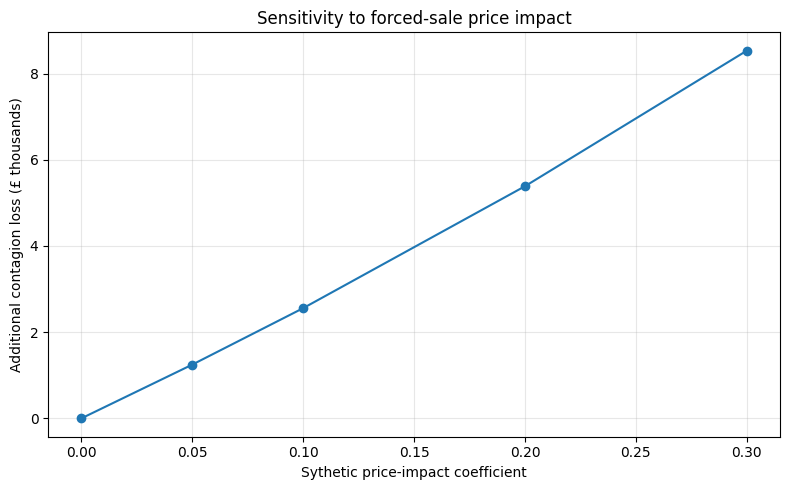

In [ ]:
import matplotlib.pyplot as plt

plot_data=stress_table.sort_values("impact_coefficient")

fig,ax=plt.subplots(figsize=(8,5))

ax.plot(
    plot_data["impact_coefficient"],
    plot_data["contagion_loss_gbp"] / 1000,
    marker="o"
)

ax.set_xlabel("Sythetic price-impact coefficient")
ax.set_ylabel("Additional contagion loss (£ thousands)")
ax.set_title("Sensitivity to forced-sale price impact")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

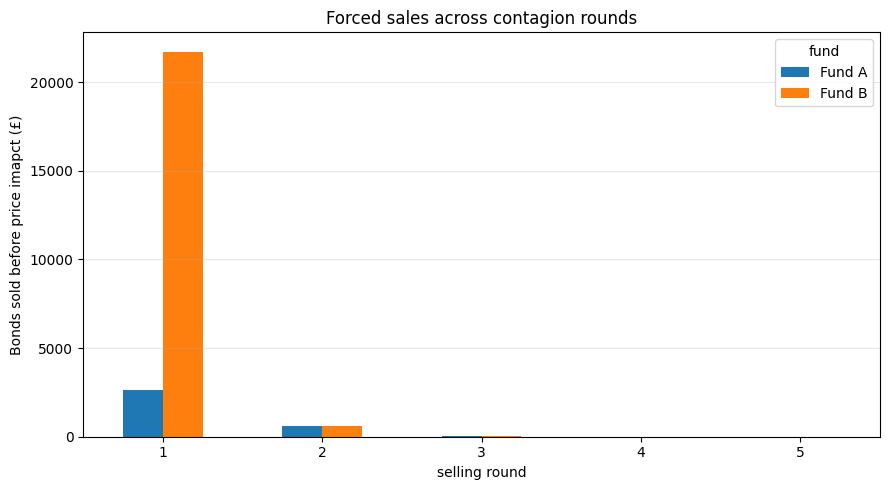

In [ ]:
sales_by_round=round_history.pivot(
    index="round",
    columns="fund",
    values="sales_before_impact_gbp"
)

ax=sales_by_round.plot(
    kind="bar",
    figsize=(9,5)
)

ax.set_xlabel("selling round")
ax.set_ylabel("Bonds sold before price imapct (£)")
ax.set_title("Forced sales across contagion rounds")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y",alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
cash_results=[]

fund_sizes=holdings.sum(axis=1) + cash
weights = holdings / holdings.sum(axis=1)[:,None]

selected_shock= historical_shocks.loc[
    shock_date,tenors
].to_numpy(dtype=float)

factors=np.exp(
    -np.array(tenors,dtype=float) * selected_shock / 10_000
)

for cash_ratio in[0.01,0.03,0.05,0.10,0.15]:
  test_cash=fund_sizes * cash_ratio
  test_holdings=(
      (fund_sizes - test_cash)[:,None]*weights
  )

  stressed=test_holdings * factors
  stressed_nav=stressed.sum(axis=1)+test_cash

  loss_fraction=np.maximum(
      0,(fund_sizes - stressed_nav) / fund_sizes
  )

  requests = (
      np.clip(base_redemption + sensitivity * loss_fraction,0,1)
      * stressed_nav
  )

  history,outcome=simulate_rounds(
      stressed, test_cash, requests, sensitivity,
      impact_coefficient=0.10
  )

  cash_results.append({
      "cash_buffer_pct":cash_ratio * 100,
      "forced_sales_gbp":history["sales_before_impact_gbp"].sum(),
      "contagion_loss_gbp":history["impact_loss_gbp"].sum(),
      "rounds":history["round"].max(),
      "status":outcome,
  })

  cash_test=pd.DataFrame(cash_results)
  print(cash_test.round(2).to_string(index=False))

 cash_buffer_pct  forced_sales_gbp  contagion_loss_gbp  rounds              status
             1.0          88058.18             8787.23       6 Withdrawals settled
 cash_buffer_pct  forced_sales_gbp  contagion_loss_gbp  rounds              status
             1.0          88058.18             8787.23       6 Withdrawals settled
             3.0          44125.01             4407.72       5 Withdrawals settled
 cash_buffer_pct  forced_sales_gbp  contagion_loss_gbp  rounds              status
             1.0          88058.18             8787.23       6 Withdrawals settled
             3.0          44125.01             4407.72       5 Withdrawals settled
             5.0            352.85               35.28       4 Withdrawals settled
 cash_buffer_pct  forced_sales_gbp  contagion_loss_gbp  rounds              status
             1.0          88058.18             8787.23       6 Withdrawals settled
             3.0          44125.01             4407.72       5 Withdrawals settled
    

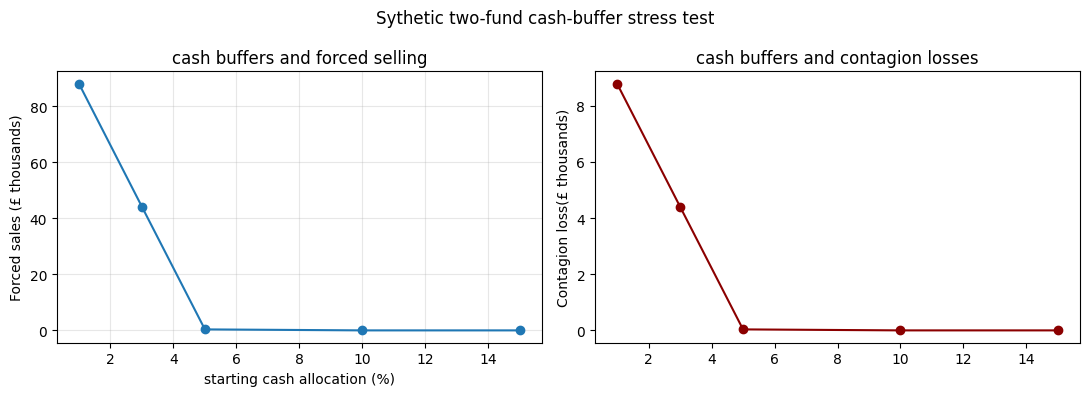

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_data=cash_test.sort_values("cash_buffer_pct")

fig,axes=plt.subplots(1,2, figsize=(11,4))

axes[0].plot(
    plot_data["cash_buffer_pct"],
    plot_data["forced_sales_gbp"] / 1000,
    marker="o"
)

axes[0].set_ylabel("Forced sales (£ thousands)")
axes[0].set_title("cash buffers and forced selling")

axes[1].plot(
    plot_data["cash_buffer_pct"],
    plot_data["contagion_loss_gbp"] / 1000,
    marker="o",
    color="darkred"
)

axes[1].set_ylabel("Contagion loss(£ thousands)")
axes[1].set_title("cash buffers and contagion losses")

for ax in axes:
  ax.set_xlabel("starting cash allocation (%)")
  ax.grid(alpha=0.3)

  fig.suptitle("Sythetic two-fund cash-buffer stress test")
  plt.tight_layout()
  plt.show()


In [ ]:
print("Shocked date:", shock_date.date())
print(cash_test.round(2).to_string(index=False))

no_sales=cash_test[
    (cash_test["forced_sales_gbp"]<=0.01)
    &(cash_test["status"] == "withdrawals settled")
]

if no_sales.empty:
  print("\n None of the tested cash buffers avoided forced selling.")
else:
  minimum_buffer=no_sales["cash_buffer_pct"].min()
  print(
      f"\n Lowest tested buffer avoiding forced selling:"f"{minimum_buffer:.1f}%"

  )

Shocked date: 2024-12-31
 cash_buffer_pct  forced_sales_gbp  contagion_loss_gbp  rounds              status
             1.0          88058.18             8787.23       6 Withdrawals settled
             3.0          44125.01             4407.72       5 Withdrawals settled
             5.0            352.85               35.28       4 Withdrawals settled
            10.0              0.00                0.00       1 Withdrawals settled
            15.0              0.00                0.00       1 Withdrawals settled

 None of the tested cash buffers avoided forced selling.


In [ ]:
multi_holdings = np.array([
    [400_000, 300_000, 200_000,  50_000,  50_000],
    [100_000, 100_000, 200_000, 300_000, 300_000],
    [200_000, 200_000, 200_000, 200_000, 200_000],
    [ 50_000,  50_000, 100_000, 300_000, 500_000],
    [300_000, 300_000, 200_000, 100_000, 100_000],
], dtype=float)

multi_cash = np.array(
    [100_000, 30_000, 50_000, 20_000, 80_000],
    dtype=float
)

multi_base = np.full(5,0.05)
multi_sensitivity=np.array([0.3,0.5,0.5,0.8,0.4])

multi_shock=historical_shocks.loc[
    shock_date,tenors
].to_numpy(dtype=float)

multi_factors=np.exp(
    -np.array(tenors,dtype=float) * multi_shock / 10_000
)

multi_stressed= multi_holdings * multi_factors
multi_initial_nav=multi_holdings.sum(axis=1)+multi_cash
multi_stressed_nav=multi_stressed.sum(axis=1)+multi_cash

multi_loss_fraction=np.maximum(
    0,(multi_initial_nav - multi_stressed_nav) / multi_initial_nav
)

multi_requests=(
    np.clip(
        multi_base + multi_sensitivity * multi_loss_fraction,0,1)
    * multi_stressed_nav
    )

multi_history,multi_status=simulate_rounds(
    multi_holdings,
    multi_cash,
    multi_requests,
    multi_sensitivity,
)

print("Shock date:",shock_date.date())
print(multi_status)

print(
    multi_history.groupby("fund").agg(
        rounds=("round","max"),
        contagion_loss_gbp=("impact_loss_gbp","sum"),
        forced_sales_gbp=("sales_before_impact_gbp","sum"),
        final_nav_gbp=("nav_gbp","last"),
        unpaid_redemptions_gbp=("unpaid_redemptions_gbp","last"),
    ).round(2).to_string()
)

Shock date: 2024-12-31
Withdrawals settled
        rounds  contagion_loss_gbp  forced_sales_gbp  final_nav_gbp  unpaid_redemptions_gbp
fund                                                                                       
Fund A       5             1152.01              0.00     1043429.96                     0.0
Fund B       5             1151.16          22261.07      976611.96                     0.0
Fund C       5             1151.91           3201.10      995649.97                     0.0
Fund D       5             1150.78          32140.70      966743.34                     0.0
Fund E       5             1152.01              0.00     1024298.45                     0.0


In [ ]:
multi_summary=multi_history.groupby("fund").agg(
    contagion_loss_gbp=("impact_loss_gbp","sum"),
    forced_sales_gbp=("sales_before_impact_gbp","sum"),
    rounds=("round","max"),
    unpaid_redemptions_gbp=("unpaid_redemptions_gbp","last")
)

multi_summary.index = (
    multi_summary.index.astype(str)
    .str.replace(" ", "", regex=False)
)

starting_values = pd.Series(
    multi_initial_nav,
    index=[f"Fund{chr(65 + i)}" for i in range(len(multi_initial_nav))]
)

multi_summary["contagion_loss_pct"] = (
    multi_summary["contagion_loss_gbp"]
    / starting_values.reindex(multi_summary.index) * 100
)
multi_summary = multi_summary.sort_values(
    "contagion_loss_pct",ascending=False
)
print("Settlement status:", multi_status)
print(multi_summary.round(2).to_string())

Settlement status: Withdrawals settled
       contagion_loss_gbp  forced_sales_gbp  rounds  unpaid_redemptions_gbp  contagion_loss_pct
fund                                                                                           
FundD             1150.78          32140.70       5                     0.0                0.11
FundB             1151.16          22261.07       5                     0.0                0.11
FundC             1151.91           3201.10       5                     0.0                0.11
FundE             1152.01              0.00       5                     0.0                0.11
FundA             1152.01              0.00       5                     0.0                0.10


In [ ]:
multi_history, multi_status = simulate_rounds(
    multi_stressed.copy(),
    multi_cash.copy(),
    multi_requests.copy(),
    multi_sensitivity.copy(),
    impact_coefficient=0.10
)

print(multi_status)

assert not multi_history.duplicated(["round", "fund"]).any(), \
    "Duplicate fund records found"

assert multi_history.groupby("round").size().eq(5).all(), \
    "Each round must contain exactly five fund records"

Withdrawals settled


In [ ]:
import numpy as np

starting_stressed_nav = (
    multi_stressed.sum() + multi_cash.sum()
)

final_nav = (
    multi_history.groupby("fund")["nav_gbp"]
    .last()
    .sum()
)

paid_withdrawals = (
    multi_history["paid_redemptions_gbp"].sum()
)

contagion_losses = (
    multi_history["impact_loss_gbp"].sum()
)

difference = (
    starting_stressed_nav
    - final_nav
    - paid_withdrawals
    - contagion_losses
)

assert np.isfinite(difference), "Accounting totals contain NaN or infinity"

assert abs(difference) <= 0.01, (
    f"Five-fund accounting difference: £{difference:,.6f}"
)

print("Five-fund accounting check passed.")
print("Total contagion loss (£):", round(contagion_losses, 2))
print("Total paid withdrawals (£):", round(paid_withdrawals, 2))

Five-fund accounting check passed.
Total contagion loss (£): 5758.08
Total paid withdrawals (£): 267509.89


In [ ]:
no_impact_history, no_impact_status = simulate_rounds(
    multi_stressed.copy(),
    multi_cash.copy(),
    multi_requests.copy(),
    multi_sensitivity.copy(),
    impact_coefficient=0.0

)

assert np.isclose(
    no_impact_history["impact_loss_gbp"].sum(),
    0.0,
    rtol=0,
    atol=0.01
),"Contagion losses must be zero when price impact is disabled"

assert no_impact_history["round"].max() == 1, \
"There fund inputs should settle in one round without price impact"

assert no_impact_status == "Withdrawals settled", \
"Unexpected unpaid withdrawals"

print("NO-price-impact validation passed.")


NO-price-impact validation passed.


In [ ]:
test_cash = multi_requests.copy() + 1_000.0

cash_history, cash_status = simulate_rounds(
    multi_stressed.copy(),
    test_cash,
    multi_requests.copy(),
    multi_sensitivity.copy(),
    impact_coefficient=0.10
)

assert np.isclose(
    cash_history["sales_before_impact_gbp"].sum(),
    0.0,rtol=0,atol=0.01
), "Funds with sufficient cash should not sell bonds"

assert np.isclose(
    cash_history["impact_loss_gbp"].sum(),
    0.0, rtol=0, atol=0.01
),"No Selling should mean no price-impact losses"

assert cash_status == "Withdrawals settled"

print("sufficient-cash validation passed.")

sufficient-cash validation passed.


In [ ]:
exhausted_history, exhausted_status = simulate_rounds(
    np.array([[1_000.0]]),
    np.array([0.0]),
    np.array([2_000.0]),
    np.array([0.0]),
    impact_coefficient=0.10
)

last = exhausted_history.iloc[-1]

assert exhausted_status == "Stopped with unpaid withdrawals"
assert np.isclose(last["nav_gbp"],0.0,atol=0.01)
assert np.isclose(last["paid_redemptions_gbp"],900.0,atol=0.01)
assert np.isclose(last["unpaid_redemptions_gbp"],1_100.0,atol=0.01)

print("Exhausted-holdings validation passed.")

Exhausted-holdings validation passed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

date_control = widgets.Dropdown(
    options=[
        (d.strftime("%Y-%m-%d"), d)
        for d in historical_shocks.index
    ],
    value=shock_date,
    description="Shock date:"
)

withdrawal_control = widgets.FloatSlider(
    value=0.05,
    min=0,
    max=0.30,
    step=0.01,
    description="Withdrawal:",
    readout_format=".0%"
)

impact_control = widgets.FloatSlider(
    value=0.10,
    min=0,
    max=0.30,
    step=0.05,
    description="Impact:"
)

run_button = widgets.Button(description="Run Scenario")
output = widgets.Output()


def update_dashboard(_):
    with output:
        clear_output(wait=True)

        date = date_control.value
        shock = historical_shocks.loc[
            date, tenors
        ].to_numpy(dtype=float)

        factors = np.exp(
            -np.array(tenors, dtype=float) * shock / 10_000
        )

        # Keep all inputs within the five-fund model
        dashboard_holdings = multi_holdings.copy()
        dashboard_cash = multi_cash.copy()
        dashboard_sensitivity = multi_sensitivity.copy()

        initial_nav = (
            dashboard_holdings.sum(axis=1) + dashboard_cash
        )

        stressed = dashboard_holdings * factors
        stressed_nav = stressed.sum(axis=1) + dashboard_cash

        loss_fraction = np.maximum(
            0, (initial_nav - stressed_nav) / initial_nav
        )

        requests = (
            np.clip(
                withdrawal_control.value
                + dashboard_sensitivity * loss_fraction,
                0, 1
            ) * stressed_nav
        )

        history, outcome = simulate_rounds(
            stressed,
            dashboard_cash,
            requests,
            dashboard_sensitivity,
            impact_coefficient=impact_control.value
        )

        summary = history.groupby("fund").agg(
            contagion_loss_gbp=("impact_loss_gbp", "sum"),
            forced_sales_gbp=("sales_before_impact_gbp", "sum"),
            final_nav_gbp=("nav_gbp", "last"),
            unpaid_redemptions_gbp=("unpaid_redemptions_gbp", "last")
        )

        print("Synthetic five-fund model")
        print(
            "Shock interval:",
            historical_shocks.loc[date, "previous_date"].date(),
            "to", date.date()
        )
        print("Status:", outcome)
        print("Rounds:", history["round"].max())
        print(
            "Initial market P&L (£):",
            round((stressed_nav - initial_nav).sum(), 2)
        )

        display(summary.round(2))

        history.pivot(
            index="round",
            columns="fund",
            values="sales_before_impact_gbp"
        ).plot(kind="bar", figsize=(9, 4))

        plt.title("Forced selling by round")
        plt.ylabel("Bonds sold before price impact (£)")
        plt.xlabel("Round")
        plt.tight_layout()
        plt.show()


run_button.on_click(update_dashboard)

display(
    widgets.VBox([
        date_control,
        withdrawal_control,
        impact_control,
        run_button,
        output
    ])
)

update_dashboard(None)